# Ćw. 2. Podstawy przepływu pracy PyTorch

Istotą uczenia maszynowego i głębokiego uczenia jest pobranie pewnych danych, zbudowanie algorytmu (takiego jak sieć neuronowa) w celu odkrycia  wzorców w danych i wykorzystania odkrytych wzorców do przewidywania przyszłości.

Można to zrobić na wiele sposobów i cały czas odkrywane są nowe architektury modeli.

Zaczniemy od linii prostej i liniowej regresji.

Zbudujemy model PyTorch, który nauczy się wzorca linii prostej i dopasuje go. Będzie to kompletny przykład budowy modelu.

## Co będziemy omawiać

Na tych zajęciach omówimy standardowy przepływ pracy PyTorch (można go w razie potrzeby posiekać i zmienić, ale obejmuje on główny zarys kroków).

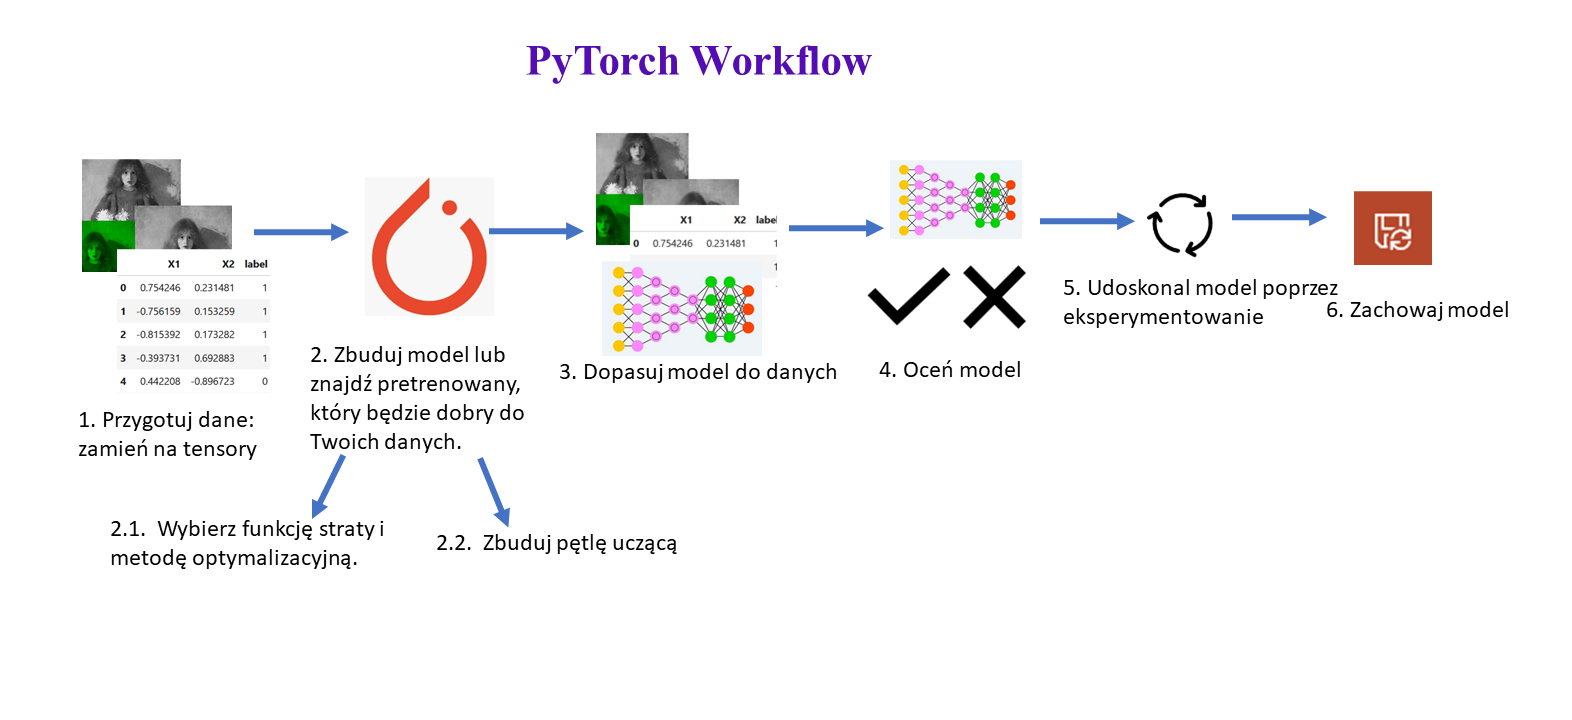

In [133]:
from IPython.display import Image
Image('/content/Obraz4.png')

Na razie użyjemy tego WorkFlow do przewidywania prostej (linii prostej), ale kroki przepływu pracy można powtarzać i zmieniać w zależności od problemu.

W szczególności zajmiemy się:

| **Temat** | **Zawartość** |
| ----- | ----- |
| **1. Przygotowanie danych** | Dane mogą być niemal dowolne, ale na początek stworzymy prostą linię prostą. |
| **2. Budowanie modelu** | Tutaj stworzymy model do nauki wzorców w danych, wybierzemy również **funkcję straty**, **optymalizator** i zbudujemy **pętlę uczącą**. |
| **3. Dopasowanie modelu do danych (trening/uczenie)** | Mamy dane i model, teraz pozwólmy modelowi (spróbować) znaleźć wzorce w danych (**treningowych**). |
| **4. Prognozowanie i ocena modelu (wnioskowanie)** | Nasz model znalazł wzorce w danych, porównajmy jego wyniki z rzeczywistymi danymi (**testowanie**). |
| **5. Zapisywanie i ładowanie modelu** | Możesz chcieć użyć swojego modelu w innym miejscu lub wrócić do niego później. |
| **6. Złożenie wszystkiego razem** | Weźmy wszystkie powyższe i połączmy. |

Gdzie znaleźć pomoc?
 [PyTorch forum](https://discuss.pytorch.org/), bardzo pomocne miejsce dla wszystkich rzeczy związanych z PyTorch..

A teraz zaimportujmy to, czego będziemy potrzebować do dzisiejszych zajęć.

Zaimportujemy `torch`, `torch.nn` (`nn` oznacza sieci neuronowe i ten pakiet zawiera bloki konstrukcyjne do tworzenia sieci neuronowych w PyTorch) i `matplotlib`.

In [134]:
import torch
from torch import nn # nn zawiera wszystkie bloki konstrukcyjne PyTorch dla sieci neuronowych
import matplotlib.pyplot as plt

# Sprawdź wersję PyTorch
torch.__version__

'2.10.0+cu128'

## 1. Dane (przygotowanie i ładowanie)

Chcę podkreślić, że „danymi” w uczeniu maszynowym może być prawie wszystko, co można sobie wyobrazić. Tabela liczb (jak duży arkusz kalkulacyjny Excel), obrazy dowolnego rodzaju, filmy (YouTube ma mnóstwo danych!), pliki audio, takie jak piosenki lub podcasty, struktury białek, tekst i wiele innych.

Uczenie maszynowe to gra składająca się z dwóch części:
1. przekształcenie danych w reprezentatywny zestaw liczb i
2. zbudowanie lub wybranie modelu w celu jak najlepszego nauczenia się reprezentacji


Zatem:
1. Przekształć swoje dane, cokolwiek to jest, w liczby (reprezentację).
2. Wybierz lub zbuduj model, aby jak najlepiej nauczyć się reprezentacji.

Czasami pierwszą i drugą część można wykonać w tym samym czasie.

Ale co, jeśli nie masz danych?

Cóż, właśnie w tym momencie jesteśmy.
Brak danych.

Ale możemy je utworzyć, albo znaleźć:
 * [zbiory danych Kaggle](https://www.kaggle.com/datasets)
 * [UCI ML](https://archive.ics.uci.edu/)
 * [Hugging Face](https://huggingface.co/)

Wygenerujemy dane do utworzenia linii prostej.

Użyjemy [regresji liniowej](https://pl.wikipedia.org/wiki/Regresja_liniowa) do stworzenia danych ze znanymi **parametrami** (wagami, których może nauczyć się model), a następnie użyjemy PyTorch, aby sprawdzić, czy możemy zbudować model do oszacowania tych parametrów za pomocą [**gradient descent/metody  spadku gradientowego**](https://pl.wikipedia.org/wiki/Metoda_najszybszego_spadku).

Nie martw się, jeśli powyższe terminy nie mają teraz większego znaczenia, zobaczymy je w akcji, a poniżej umieszczę dodatkowe zasoby, z których możesz dowiedzieć się więcej.


In [135]:
# Zadaj "znane" parametry
weight = 0.7
bias = 0.3

# Utwórz dane
start = 0
end = 1
step = 0.02
X = torch.arange(start, end, step).unsqueeze(dim=1)
y = weight * X + bias

X[:10], y[:10]

(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800],
         [0.1000],
         [0.1200],
         [0.1400],
         [0.1600],
         [0.1800]]),
 tensor([[0.3000],
         [0.3140],
         [0.3280],
         [0.3420],
         [0.3560],
         [0.3700],
         [0.3840],
         [0.3980],
         [0.4120],
         [0.4260]]))

Super! Teraz przejdziemy do budowania modelu, który może nauczyć się relacji między `X` (**cechy**) i `y` (**etykiety**).

### Podział danych na zbiór uczący i testowy

Mamy już trochę danych.

Ale zanim zbudujemy model, musimy je podzielić.

Jednym z najważniejszych kroków w projekcie uczenia maszynowego jest utworzenie zestawu treningowego i testowego (oraz, w razie potrzeby, zestawu walidacyjnego).

Każdy podział zbioru danych służy określonemu celowi:

| Podział | Cel | Ilość całkowitych danych | Jak często jest używany? |
| ----- | ----- | ----- | ----- |
| **Zestaw treningowy** | Model uczy się na podstawie tych danych (jak materiały z kursu, których uczysz się w trakcie semestru). | ~60-80% | Zawsze |
**Zestaw walidacyjny** | Model jest dostrajany na podstawie tych danych (np. egzamin praktyczny przed egzaminem końcowym). | ~10-20% | Często, ale nie zawsze |
**Zestaw testowy** | Model jest oceniany na tych danych, aby sprawdzić, czego się nauczył (np. egzamin końcowy na koniec semestru). | ~10-20% | Zawsze |

Na razie użyjemy tylko zestawu treningowego i testowego, co oznacza, że będziemy mieć zestaw danych, na których nasz model będzie się uczył i na których będzie oceniany.

Możemy je utworzyć, dzieląc nasze tensory `X` i `y`.
> **Uwaga:** Gdy mamy do czynienia z rzeczywistymi danymi, ten krok jest zwykle wykonywany na samym początku projektu (zestaw testowy powinien być zawsze oddzielony od wszystkich innych danych). Chcemy, aby nasz model uczył się z danych treningowych, a następnie oceniał je na danych testowych, aby uzyskać wskazanie, jak dobrze **generalizuje** na niewidocznych przykładach.


In [136]:
# Podziel dane na zbiór uczący i testowy
train_split = int(0.8 * len(X)) # 80% danych na potrzeby uczenia, 20% na testowanie
X_train, y_train = X[:train_split], y[:train_split]
X_test, y_test = X[train_split:], y[train_split:]

len(X_train), len(y_train), len(X_test), len(y_test)

(40, 40, 10, 10)

Wspaniale, mamy 40 próbek do trenowania (`X_train` i `y_train`) i 10 próbek do testowania (`X_test` i `y_test`).

Stworzony przez nas model będzie próbował nauczyć się relacji między `X_train` i `y_train`, a następnie ocenimy to, czego się nauczy na `X_test` i `y_test`.

Ale teraz nasze dane to tylko liczby na stronie.

Stwórzmy funkcję do ich wizualizacji.

In [137]:
def plot_predictions(train_data=X_train,
                     train_labels=y_train,
                     test_data=X_test,
                     test_labels=y_test,
                     predictions=None):
  """
  Wykreśla dane treningowe, dane testowe i porównuje prognozy.
  """
  plt.figure(figsize=(10, 7))

  # tworzy niebieski wykres danych uczących
  plt.scatter(train_data, train_labels, c="b", s=4, label="Dane uczące")

  # Dane testowe są zielone
  plt.scatter(test_data, test_labels, c="g", s=4, label="Dane testowe")

  if predictions is not None:
    # Wykreśl przewidywania na czerwono (przewidywania zostały wykonane na danych testowych).
    plt.scatter(test_data, predictions, c="r", s=4, label="Przewidywania")

  # Pokaż legendę
  plt.legend(prop={"size": 14});

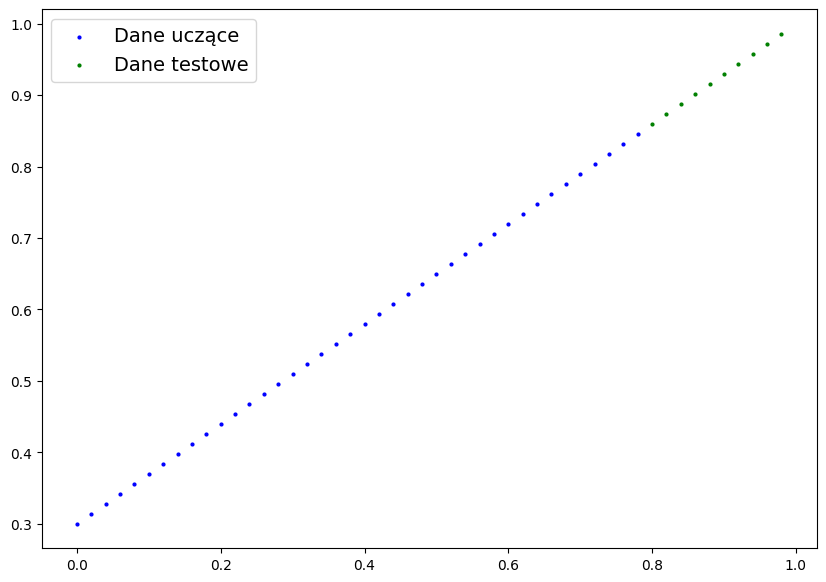

In [138]:
plot_predictions();

Super!

Teraz zamiast liczb na stronie, nasze dane są linią prostą.

> **Uwaga:** Teraz jest dobry moment, aby przedstawić motto eksploratora danych... „wizualizuj, wizualizuj, wizualizuj!”.
>
> Pomyśl o tym za każdym razem, gdy pracujesz z danymi i przekształcasz je w liczby, jeśli możesz coś zwizualizować.

## 2. Zbuduj model

Teraz mamy trochę danych, zbudujmy model, aby użyć niebieskich kropek do przewidywania zielonych kropek.

Zamierzamy od razu przejść do działania.

Najpierw napiszemy kod, a następnie wszystko wyjaśnimy.

Powielmy standardowy model regresji liniowej przy użyciu czystego PyTorch.

In [139]:
# Utwórz klasę modelu regresji liniowej
class ModelRegresjiLiniowej(nn.Module): # <- prawie wszystko w PyTorch jest nn.Module (można to potraktować jako klocki lego sieci neuronowych)
    def __init__(self):
        super().__init__()
        self.weights = nn.Parameter(torch.randn(1, # <- Rozpocznij od losowych wag (zostaną one dostosowane w miarę uczenia się modelu).
                                                dtype=torch.float), # <- PyTorch lubi float32
                                   requires_grad=True) # <- czy możemy zaktualizować tę wartość za pomocą spadku gradientowego?

        self.bias = nn.Parameter(torch.randn(1, # <- rozpocząć z losowym obciążeniem (zostanie ono dostosowane w miarę uczenia się modelu)
                                            dtype=torch.float), # <- PyTorch  lubi float32
                                requires_grad=True) # <- czy możemy zaktualizować tę wartość za pomocą spadku gradientowego?

    # Forward definiuje obliczenia w modelu.
    def forward(self, x: torch.Tensor) -> torch.Tensor: # <- "x" to input (np. zmienne/cechy uczące/testowe)
        return self.weights * x + self.bias # <- jest wzorem funkcji liniowej (y = a*x + b)

W porządku, powyżej dzieje się sporo, ale podzielmy to na części.

> **Zasoby:** Będziemy używać klas Pythona do tworzenia elementów sieci neuronowych. Jeśli nie jesteś zaznajomiony z notacją klas Pythona, polecam przeczytanie [Real Python's Object Orientating programming in Python 3 guide](https://realpython.com/python3-object-oriented-programming/) kilka razy.


### Podstawy tworzenia modeli w PyTorch
PyTorch posiada cztery podstawowe moduły, których można użyć do stworzenia niemal każdego rodzaju sieci neuronowej, jaką można sobie wyobrazić.

Są to [`torch.nn`](https://pytorch.org/docs/stable/nn.html), [`torch.optim`](https://pytorch.org/docs/stable/optim.html), [`torch.utils.data.Dataset`](https://pytorch.org/docs/stable/data.html#torch.utils.data.Dataset) i [`torch.utils.data.DataLoader`](https://pytorch.org/docs/stable/data.html). Na razie skupimy się na dwóch pierwszych, a do pozostałych dwóch przejdziemy później (choć być może będziesz w stanie zgadnąć, co robią).

| Moduł PyTorch | Co robi? |
| ----- | ----- |
| [`torch.nn`](https://pytorch.org/docs/stable/nn.html) | Zawiera szystkie  bloki konstrukcyjne dla grafów obliczeniowych (zasadniczo serii obliczeń wykonywanych w określony sposób). |
| [`torch.nn.Parameter`](https://pytorch.org/docs/stable/generated/torch.nn.parameter.Parameter.html#parameter) | Przechowuje tensory, które mogą być używane z `nn.Module`. Jeśli `requires_grad=True` gradienty (używane do aktualizacji parametrów modelu poprzez [**gradient descent**](https://ml-cheatsheet.readthedocs.io/en/latest/gradient_descent.html)) są obliczane automatycznie, jest to często określane jako „autograd”.  |
| [`torch.nn.Module`](https://pytorch.org/docs/stable/generated/torch.nn.Module.html#torch.nn.Module) | Klasa bazowa dla wszystkich modułów sieci neuronowych, wszystkie elementy składowe sieci neuronowych są podklasami. Jeśli budujesz sieć neuronową w PyTorch, twoje modele powinny podklasować `nn.Module`. Wymaga zaimplementowania metody `forward()`. |
| [`torch.optim`](https://pytorch.org/docs/stable/optim.html) | Zawiera różne algorytmy optymalizacji (mówią one parametrom modelu przechowywanym w `nn.Parameter`, jak najlepiej zmienić, aby poprawić zejście gradientowe, a tym samym zmniejszyć straty). |

Wszystkie podklasy `nn.Module` wymagają metody `forward()`, która definiuje obliczenia, które będą miały miejsce na danych przekazanych do konkretnego `nn.Module` (np. formuła regresji liniowej powyżej).

Jeśli powyższe brzmi skomplikowanie, pomyśl w ten sposób, że prawie wszystko w sieci neuronowej PyTorch pochodzi z `torch.nn`,
* `nn.Module` zawiera większe bloki konstrukcyjne (warstwy)
* `nn.Parameter` zawiera mniejsze parametry, takie jak wagi i odchylenia (połącz je razem, aby utworzyć `nn.Module`)
* `forward()` mówi większym blokom, jak wykonywać obliczenia na danych wejściowych (tensorach pełnych danych) w ramach `nn.Module`
* `torch.optim` zawiera metody optymalizacji, jak poprawić parametry w `nn.Parameter`, aby lepiej reprezentowały dane wejściowe

Podstawowe bloki konstrukcyjne do tworzenia modelu PyTorch poprzez podklasowanie `nn.Module`. Dla obiektów, które podklasują `nn.Module`, musi być zdefiniowana metoda `forward()`.

> **Odnośniki:** Więcej informacji na temat tych niezbędnych modułów i przypadków ich użycia można znaleźć w ['PyTorch Cheat Sheet'](https://pytorch.org/tutorials/beginner/ptcheat.html).


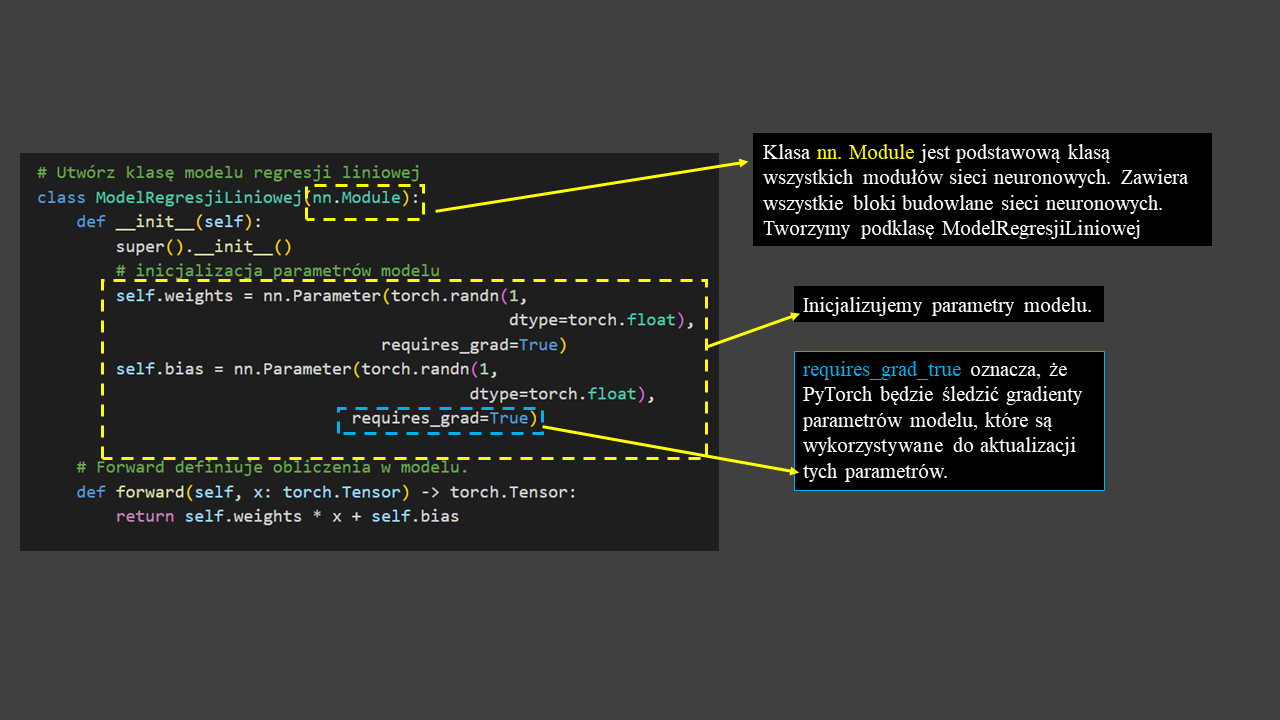

In [140]:
from IPython.display import Image
Image('./Obraz5.png')

### Sprawdzanie zawartości modelu PyTorch
Teraz mamy to już za sobą, stwórzmy instancję modelu z klasą, którą stworzyliśmy i sprawdźmy jej parametry za pomocą [`.parameters()`](https://pytorch.org/docs/stable/generated/torch.nn.Module.html#torch.nn.Module.parameters).

In [141]:
# zainicjuj losowe ziarno, ponieważ nn.parametr jest inicjowany losowo
torch.manual_seed(42)

# Utwórz instancję modelu (jest to podklasa nn.Module, która zawiera nn.Parameter(s)).
model_0 = ModelRegresjiLiniowej()

# Sprawdź nn.Parameter(s) w utworzonej przez nas podklasie nn.Module
list(model_0.parameters())

[Parameter containing:
 tensor([0.3367], requires_grad=True),
 Parameter containing:
 tensor([0.1288], requires_grad=True)]

Możemy również uzyskać opis (co zawiera model) modelu za pomocą [`.state_dict()`](https://pytorch.org/docs/stable/generated/torch.nn.Module.html#torch.nn.Module.state_dict).

In [142]:
# Lista nazwanych parametrów
model_0.state_dict()

OrderedDict([('weights', tensor([0.3367])), ('bias', tensor([0.1288]))])

Zauważ jak wartości `weights` i `bias` z `model_0.state_dict()` wychodzą jako losowe tensory float.

To dlatego, że zainicjowaliśmy je powyżej za pomocą `torch.randn()`.

Zasadniczo chcemy zacząć od losowych parametrów i sprawić, by model zaktualizował je w kierunku parametrów, które najlepiej pasują do naszych danych (zakodowane wartości `weight` i `bias`, które ustawiliśmy podczas tworzenia naszych danych linii prostej).

> **Ćwiczenie:** Spróbuj zmienić wartość `torch.manual_seed()` dwie komórki powyżej, zobacz co stanie się z wartościami wag i bias.

Ponieważ nasz model zaczyna się od losowych wartości, teraz będzie miał słabą moc predykcyjną.


### Tworzenie przewidywań za pomocą `torch.inference_mode()`
Aby to sprawdzić, możemy przekazać dane testowe `X_test`, aby zobaczyć, jak dokładnie przewidują `y_test`.

Kiedy przekazujemy dane do naszego modelu, przejdzie on przez metodę `forward()` modelu i wygeneruje wynik za pomocą obliczeń, które zdefiniowaliśmy.

Dokonajmy kilku przewidywań.

In [143]:
# Prognoza z modelu
with torch.inference_mode():
    y_preds = model_0(X_test)

# Uwaga: w starszym kodzie PyTorch możesz również zobaczyć torch.no_grad()
# with torch.no_grad():
# y_preds = model_0(X_test)



Prawdopodobnie zauważyłeś, że użyliśmy [`torch.inference_mode()`](https://pytorch.org/docs/stable/generated/torch.inference_mode.html) jako [menedżera kontekstu](https://realpython.com/python-with-statement/) (to właśnie jest `with torch.inference_mode():`) do tworzenia prognoz.

Jak sama nazwa wskazuje, `torch.inference_mode()` jest używany podczas używania modelu do wnioskowania (tworzenia prognoz).

Funkcja `torch.inference_mode()` wyłącza kilka rzeczy (takich jak śledzenie gradientu, które jest niezbędne do uczenia, ale nie do wnioskowania), aby **przejścia do przodu** (dane przechodzące przez metodę `forward()`) były szybsze.

> **Uwaga:** W starszym kodzie PyTorch, można również zobaczyć `torch.no_grad()` używany do wnioskowania. Podczas gdy `torch.inference_mode()` i `torch.no_grad()` robią podobne rzeczy,
`torch.inference_mode()` jest nowszy, potencjalnie szybszy i preferowany. Zobacz ten [Tweet z PyTorch](https://twitter.com/PyTorch/status/1437838231505096708?s=20) po więcej.

Dokonaliśmy pewnych przewidywań, zobaczmy jak one wyglądają.

In [144]:
# Sprawdź wartości przewidzywane
print(f"Liczba próbek testowych: {len(X_test)}")
print(f"Liczba wartości przewidzianych: {len(y_preds)}")
print(f"Wartości przewidziane:\n{y_preds}")

Liczba próbek testowych: 10
Liczba wartości przewidzianych: 10
Wartości przewidziane:
tensor([[0.3982],
        [0.4049],
        [0.4116],
        [0.4184],
        [0.4251],
        [0.4318],
        [0.4386],
        [0.4453],
        [0.4520],
        [0.4588]])


Zauważ, że na każdą próbkę testową przypada jedna wartość predykcyjna.

Wynika to z rodzaju danych, których używamy. Dla naszej linii prostej jedna wartość `X` mapuje jedną wartość `y`.

Jednak modele uczenia maszynowego są bardzo elastyczne. Możesz mieć 100 wartości `X` mapujących jedną, dwie, trzy lub 10 wartości `y`. Wszystko zależy od tego, nad czym pracujesz.

Nasze przewidywania są nadal liczbami na stronie, zwizualizujmy je za pomocą naszej funkcji `plot_predictions()`, którą utworzyliśmy powyżej.

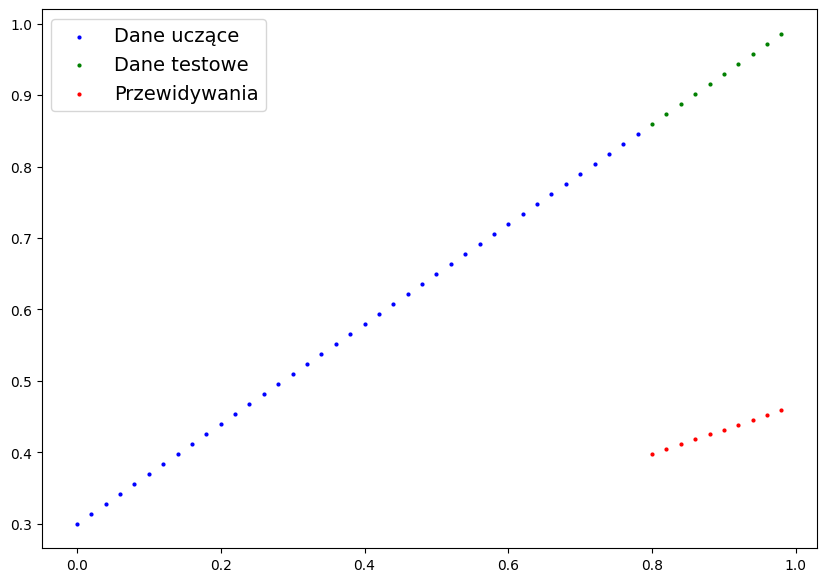

In [145]:
plot_predictions(predictions=y_preds)

In [146]:
y_test - y_preds

tensor([[0.4618],
        [0.4691],
        [0.4764],
        [0.4836],
        [0.4909],
        [0.4982],
        [0.5054],
        [0.5127],
        [0.5200],
        [0.5272]])

Niestety! Te prognozy wyglądają dość kiepsko...

Ma to jednak sens, gdy pamiętamy, że nasz model wykorzystuje losowe wartości parametrów do tworzenia prognoz.

Nawet nie spojrzał na niebieskie kropki, aby spróbować przewidzieć zielone kropki.

Czas to zmienić.

## 3. Uczenie modelu

W tej chwili nasz model tworzy prognozy przy użyciu losowych parametrów do obliczeń, w zasadzie zgaduje (losowo).

Aby to naprawić, możemy zaktualizować jego wewnętrzne parametry (odnoszę się również do *parametrów* jako wzorców), wartości `weights` i `bias`, które ustawiliśmy losowo za pomocą `nn.Parameter()` i `torch.randn()`, aby były czymś, co lepiej reprezentuje dane.

Moglibyśmy zakodować to na sztywno (skoro znamy domyślne wartości `weight=0.7` i `bias=0.3`), ale gdzie w tym zabawa?

Przez większość czasu nie będziesz wiedział, jakie są idealne parametry dla modelu.

Zamiast tego o wiele przyjemniej jest napisać kod, aby sprawdzić, czy model może sam spróbować je rozgryźć.



### Tworzenie funkcji straty i optymalizatora w PyTorch

Aby nasz model mógł samodzielnie aktualizować swoje parametry, będziemy musieli dodać jeszcze kilka rzeczy do naszego przepisu.

Jest to **funkcja straty/loss function** oraz **optymalizator**.

Są to:

| Funkcja | Co robi? | Gdzie znajduje się w PyTorch? | Przykłady |
| ----- | ----- | ----- | ----- |
| **loss** |Mierzy, jak błędne są przewidywania modelu (np. `y_preds`) w porównaniu do etykiet prawdy (np. `y_test`). Im niższa, tym lepiej. | PyTorch ma wiele wbudowanych funkcji straty w [`torch.nn`](https://pytorch.org/docs/stable/nn.html#loss-functions). | Średni błąd bezwzględny (MAE) dla problemów regresji ([`torch.nn.L1Loss()`](https://pytorch.org/docs/stable/generated/torch.nn.L1Loss.html)).  Binarna entropia krzyżowa dla problemów klasyfikacji binarnej ([`torch.nn.BCELoss()`](https://pytorch.org/docs/stable/generated/torch.nn.BCELoss.html)).  |
| **Optimizer** | Mówi modelowi, jak zaktualizować jego wewnętrzne parametry, aby jak najlepiej obniżyć stratę. | Różne implementacje funkcji optymalizacji można znaleźć w [`torch.optim`](https://pytorch.org/docs/stable/optim.html). | Stochastic gradient descent ([`torch.optim.SGD()`](https://pytorch.org/docs/stable/generated/torch.optim.SGD.html#torch.optim.SGD)). Optymalizator Adam ([`torch.optim.Adam()`](https://pytorch.org/docs/stable/generated/torch.optim.Adam.html#torch.optim.Adam)). |

Stwórzmy funkcję straty i optymalizator, których możemy użyć do ulepszenia naszego modelu.

W zależności od rodzaju problemu, nad którym pracujesz, będzie zależeć od funkcji straty i optymalizatora, którego użyjesz.

Istnieją jednak pewne typowe wartości, o których wiadomo, że działają dobrze, takie jak SGD (stochastic gradient descent) lub optymalizator Adam. I funkcja straty MAE (średni błąd bezwzględny) dla problemów regresji (przewidywanie liczby) lub binarna funkcja straty entropii krzyżowej dla problemów klasyfikacji (przewidywanie jednej lub drugiej klasy).

Dla naszego problemu, ponieważ przewidujemy liczbę, użyjmy MAE (który jest pod `torch.nn.L1Loss()`) w PyTorch jako naszej funkcji straty.


*Średni błąd bezwzględny (MAE, w PyTorch: `torch.nn.L1Loss`) mierzy bezwzględną różnicę między dwoma punktami (przewidywaniami i etykietami), a następnie oblicza średnią ze wszystkich przykładów.

Użyjemy SGD, `torch.optim.SGD(params, lr)` gdzie:

* `params` to docelowe parametry modelu, które chcielibyśmy zoptymalizować (np. wartości `weights` i `bias`, które losowo ustawiliśmy wcześniej).
* `lr` to **szybkość uczenia**, z jaką optymalizator ma aktualizować parametry, wyższa oznacza, że optymalizator będzie próbował większych kroków (czasami mogą one być zbyt duże i optymalizator nie będzie działał), niższa oznacza, że optymalizator będzie próbował mniejszych aktualizacji (czasami mogą one być zbyt małe i optymalizator będzie potrzebował zbyt wiele czasu, aby znaleźć idealne wartości). Szybkość uczenia się jest uważana za **hiperparametr** (ponieważ jest ustawiana przez użytkownika). Typowe wartości początkowe dla współczynnika uczenia to `0,01`, `0,001`, `0,0001`, jednak można je również dostosowywać w czasie (nazywa się to [dostosowaniem współczynnika uczenia](https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate)).

Woah, to dużo, zobaczmy to w kodzie.

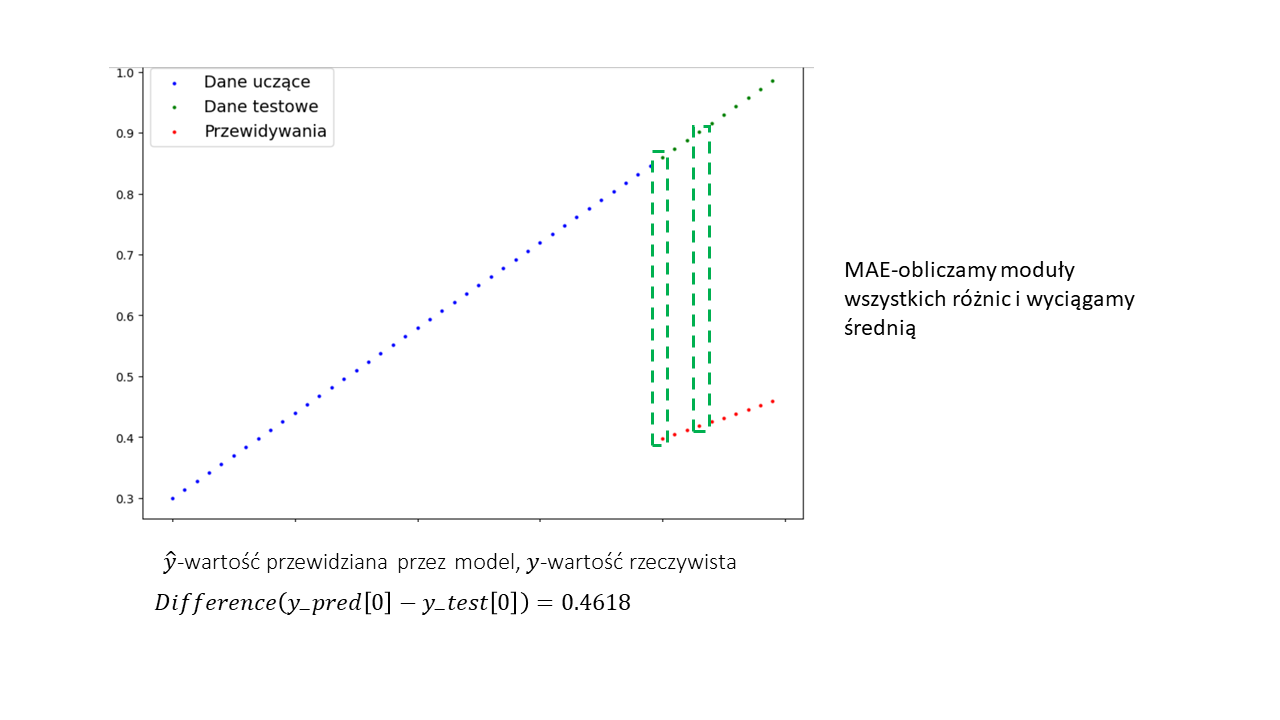

In [147]:
from IPython.display import Image
Image('./Obraz6.png')

In [148]:
# Tworzenie funkcji kosztu/straty (loss function)
loss_fn = nn.L1Loss() # MAE jest takie samo jak L1Loss

# Tworzenie optymalizatora
optimizer = torch.optim.SGD(params=model_0.parameters(), # parametry modelu, które mają być optymalizowane
                            lr=0.01) # szybkość uczenia się (jak bardzo optymalizator powinien zmieniać parametry w każdym kroku, wyższa=więcej (mniej stabilne), niższa=mniej (może zająć dużo czasu))

### Tworzenie pętli optymalizacyjnej w PyTorch

Woohoo! Teraz mamy funkcję straty i optymalizator, nadszedł czas, aby utworzyć **pętlę treningową** (i **pętlę testową**).

Pętla treningowa obejmuje model przechodzący przez dane treningowe i uczący się relacji między „cechami” i „etykietami”.

Pętla testowa polega na przejściu przez dane testowe i ocenie, jak dobre są wzorce, których model nauczył się na danych treningowych (model nigdy nie widzi danych testowych podczas treningu).

Każdy z tych etapów nazywany jest „pętlą”, ponieważ chcemy, aby nasz model przyjrzał się każdej próbce w każdym zestawie danych.




### Pętla ucząca w PyTorch
W przypadku pętli szkoleniowej zbudujemy następujące kroki:

| Numer | Nazwa kroku | Co to robi? | Przykład kodu |
| ----- | ----- | ----- | ----- |
| 1 | Krok w przód (Forward pass, propagacja w  przód)| Model jednokrotnie przegląda wszystkie dane szkoleniowe, wykonując obliczenia funkcji „forward()”. | `model(x_train)` |
| 2 | Obliczenie straty, błędu | Wyniki modelu (przewidywania) porównuje się z rzeczywistą wartością i ocenia, aby sprawdzić, jak bardzo się mylą. | `loss = loss_fn(y_pred, y_train)` |
| 3 |Wyzerowanie gradientów | Gradienty optymalizatorów są ustawione na zero (domyślnie są akumulowane), dzięki czemu można je ponownie obliczyć dla konkretnego etapu uczenia. | `optimizer.zero_grad()` |
| 4 | Wykonaj propagację wsteczną dla straty | Oblicza gradient straty w odniesieniu do każdego parametru modelu, który ma zostać zaktualizowany (każdy parametr z wartością „requires_grad=True”). Nazywa się to **propagacją wsteczną**, stąd „backward”.  | `loss.backward()` |
| 5 | Zaktualizuj optymalizator (**spadek gradientowy**) | Zaktualizuj parametry za pomocą `requires_grad=True` w odniesieniu do gradientów strat, aby je poprawić. | `optimizer.step()` |

> **Uwaga:** Powyższe jest tylko jednym przykładem tego, jak można uporządkować lub opisać kroki. Z doświadczeniem przekonasz się, że tworzenie pętli uczących w PyTorch może być dość elastyczne.
>
> A jeśli chodzi o uporządkowanie rzeczy, powyższe jest dobrym domyślnym porządkiem, ale możesz zobaczyć nieco inne porządki. Oto kilka praktycznych zasad:
> * Oblicz stratę (`loss = ...`) *przed* wykonaniem propagacji wstecznej (`loss.backward()`).
> * Zerowanie gradientów (`optimizer.zero_grad()`) *przed* obliczeniem gradientów straty względem każdego parametru modelu (`loss.backward()`).
> * Krok optymalizatora (`optimizer.step()`) *po* wykonaniu propagacji wstecznej straty (`loss.backward()`).

Aby uzyskać zasoby pomagające zrozumieć, co dzieje się za kulisami propagacji wstecznej i spadku gradientowego, zobacz sekcję dotyczącą zajęć dodatkowych.


### Pętla testowa w PyTorch

Jeśli chodzi o pętlę testową (ocenę naszego modelu), typowe kroki obejmują:

| Numer | Nazwa kroku | Co robi? | Przykład kodu |
| ----- | ----- | ----- | ----- |
| 1 | Propagacja w przód | Model przechodzi przez wszystkie dane testowe raz, wykonując obliczenia funkcji `forward()`. | `model(x_test)` |
| 2 | Obliczenie straty | Wyniki modelu (prognozy) są porównywane z prawdą i oceniane, aby zobaczyć, jak bardzo są błędne. | ​​`loss = loss_fn(y_pred, y_test)` |
| 3 | Obliczenie metryki oceny (opcjonalnie) | Oprócz wartości straty możesz chcieć obliczyć inne metryki oceny, takie jak dokładność w zestawie testowym. | Funkcje niestandardowe |

Zwróć uwagę, że pętla testowa nie zawiera wykonywania propagacji wstecznej (`loss.backward()`) ani krokowego wykonywania optymalizatora (`optimizer.step()`), ponieważ żadne parametry w modelu nie są zmieniane podczas testowania, zostały już obliczone. Na potrzeby testowania interesuje nas tylko wynik przejścia do przodu przez model.


Zbierzmy wszystkie powyższe informacje i przeszkolmy nasz model przez 100 **epok** (przebiegów danych w przód), a następnie będziemy go oceniać co 10 epok.


In [149]:
torch.manual_seed(42)

# Ustaw liczbę epok (ile razy model przejdzie pętlę z danymi uczącymi)
epochs = 100

# Utwórz puste listy strat, aby śledzić wartości
train_loss_values = []
test_loss_values = []
epoch_count = []

for epoch in range(epochs):
    ### Uczenie
    # Przełącz model w tryb treningowy (jest to domyślny stan modelu)
    model_0.train()

    # 1. Przekaż dane do przodu za pomocą metody forward()
    y_pred = model_0(X_train)
    # print(y_pred)

    # 2. Oblicz stratę (jak bardzo nasze przewidywania modelu różnią się od prawdziwych wartości)
    loss = loss_fn(y_pred, y_train)

    # 3. Wyzeruj gradient
    optimizer.zero_grad()

    # 4. Wykonaj propagację wsteczną, oblicz gradienty funkcji straty względem
    loss.backward()

    # 5. Zaktualizuj parametry modelu wykorzystując wybrany algorytm optymalizacyjny (np. SGD, Adam)
    optimizer.step()

    ### Testowanie

    # Oceń model
    model_0.eval()

    with torch.inference_mode():
      # 1. Przekaż dane testowe krokiem do przodu (propagacja w przód)
      test_pred = model_0(X_test)

      # 2. Oblicz stratę na danych testowych
      test_loss = loss_fn(test_pred, y_test.type(torch.float)) # przewidywania są w typie danych torch.float, więc porównania muszą być wykonywane z tensorami tego samego typu

      # Wydrukuj wyniki
      if epoch % 10 == 0:
            epoch_count.append(epoch)
            train_loss_values.append(loss.detach().numpy())
            test_loss_values.append(test_loss.detach().numpy())
            print(f"Epoch: {epoch} | MAE Train Loss: {loss} | MAE Test Loss: {test_loss} ")

Epoch: 0 | MAE Train Loss: 0.31288138031959534 | MAE Test Loss: 0.48106518387794495 
Epoch: 10 | MAE Train Loss: 0.1976713240146637 | MAE Test Loss: 0.3463551998138428 
Epoch: 20 | MAE Train Loss: 0.08908725529909134 | MAE Test Loss: 0.21729660034179688 
Epoch: 30 | MAE Train Loss: 0.053148526698350906 | MAE Test Loss: 0.14464017748832703 
Epoch: 40 | MAE Train Loss: 0.04543796554207802 | MAE Test Loss: 0.11360953003168106 
Epoch: 50 | MAE Train Loss: 0.04167863354086876 | MAE Test Loss: 0.09919948130846024 
Epoch: 60 | MAE Train Loss: 0.03818932920694351 | MAE Test Loss: 0.08886633068323135 
Epoch: 70 | MAE Train Loss: 0.03476089984178543 | MAE Test Loss: 0.0805937647819519 
Epoch: 80 | MAE Train Loss: 0.03132382780313492 | MAE Test Loss: 0.07232122868299484 
Epoch: 90 | MAE Train Loss: 0.02788739837706089 | MAE Test Loss: 0.06473556160926819 


 Wygląda na to, że nasza strata maleje z każdą epoką.

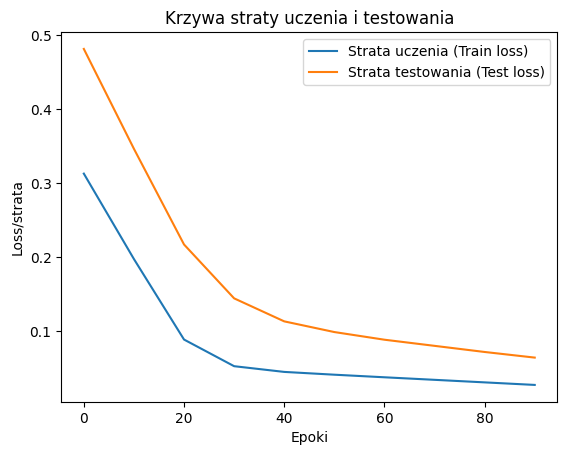

In [150]:
# Wykres funkcji straty
plt.plot(epoch_count, train_loss_values, label="Strata uczenia (Train loss)")
plt.plot(epoch_count, test_loss_values, label="Strata testowania (Test loss)")
plt.title("Krzywa straty uczenia i testowania")
plt.ylabel("Loss/strata")
plt.xlabel("Epoki")
plt.legend();

Świetnie! **Krzywe strat** pokazują, że strata maleje w czasie. Pamiętaj, strata jest miarą tego, jak *błędny* jest Twój model, więc im niższa, tym lepiej.

Ale dlaczego strata spadła?

Cóż, dzięki naszej funkcji strat i optymalizatorowi, wewnętrzne parametry modelu (`weights` i `bias`) zostały zaktualizowane, aby lepiej odzwierciedlać podstawowe wzorce w danych.

Przyjrzyjmy się [`.state_dict()`](https://pytorch.org/tutorials/recipes/recipes/what_is_state_dict.html) naszego modelu, aby zobaczyć, jak bardzo nasz model zbliża się do oryginalnych wartości, które ustawiliśmy dla wag i odchyleń.


In [151]:
# Znajdź wyuczone parametry naszego modelu
print("Model nauczył się następujących wartości wag i obciążenia:")
print(model_0.state_dict())
print("\nA wyjściowe wartości wag i obciażenia były:")
print(f"wagi: {weight}, obciążenie: {bias}")

Model nauczył się następujących wartości wag i obciążenia:
OrderedDict({'weights': tensor([0.5784]), 'bias': tensor([0.3513])})

A wyjściowe wartości wag i obciażenia były:
wagi: 0.7, obciążenie: 0.3


Wow! Jakie to fajne?

Nasz model był bardzo blisko obliczenia dokładnych oryginalnych wartości dla `weight` i `bias` (i prawdopodobnie byłby jeszcze bliżej, gdybyśmy trenowali go dłużej).

> **Ćwiczenie:** Spróbuj zmienić wartość `epochs` powyżej na 200, co się stanie z krzywymi strat oraz wartościami parametrów wag i bias modelu?

Prawdopodobnie nigdy nie odgadnie ich *idealnie* (szczególnie przy użyciu bardziej skomplikowanych zestawów danych), ale to w porządku, często można zrobić bardzo fajne rzeczy z bliskim przybliżeniem.

To jest cała idea uczenia maszynowego i głębokiego uczenia, **istnieją pewne idealne wartości, które opisują nasze dane** i zamiast ustalać je ręcznie, **możemy wytrenować model, aby ustalał je programowo**.

## 4. Tworzenie prognoz z wytrenowanym modelem PyTorch (wnioskowanie)

Po wytrenowaniu modelu prawdopodobnie będziesz chciał tworzyć prognozy z jego użyciem.

Widzieliśmy już fragment tego w kodzie treningowym i testowym powyżej, kroki, aby to zrobić poza pętlą treningową/testową są podobne.

Istnieją trzy rzeczy, o których należy pamiętać podczas tworzenia prognoz (nazywanych również wykonywaniem wnioskowania) z modelem PyTorch:

1. Ustaw model w trybie oceny (`model.eval()`).
2. Wykonaj prognozy za pomocą menedżera kontekstu trybu wnioskowania (`with torch.inference_mode(): ...`).
3. Wszystkie prognozy powinny być tworzone z obiektami na tym samym urządzeniu (np. dane i model tylko na GPU lub dane i model tylko na CPU).

Pierwsze dwa elementy zapewniają, że wszystkie pomocne obliczenia i ustawienia, których PyTorch używa w tle podczas treningu, ale nie są niezbędne do wnioskowania, są wyłączone (co powoduje szybsze obliczenia). A trzeci zapewnia, że ​​nie napotkasz błędów między urządzeniami.

In [ ]:
# 1. Poddaj model ewaluacji
model_0.eval()

# 2. Skonfiguruj menedżera kontekstu trybu wnioskowania
with torch.inference_mode():
  # 3. Upewnij się, że obliczenia są wykonywane z modelem i danymi na tym samym urządzeniu
# w naszym przypadku nie skonfigurowaliśmy jeszcze kodu niezależnego od urządzenia, więc nasze dane i model są
# domyślnie na CPU.
# model_0.to(device)
# X_test = X_test.to(device)
  y_preds = model_0(X_test)
y_preds

tensor([[0.8141],
        [0.8256],
        [0.8372],
        [0.8488],
        [0.8603],
        [0.8719],
        [0.8835],
        [0.8950],
        [0.9066],
        [0.9182]])

Świetnie! Dokonaliśmy kilku przewidywań z naszym wytrenowanym modelem, jak teraz wyglądają?

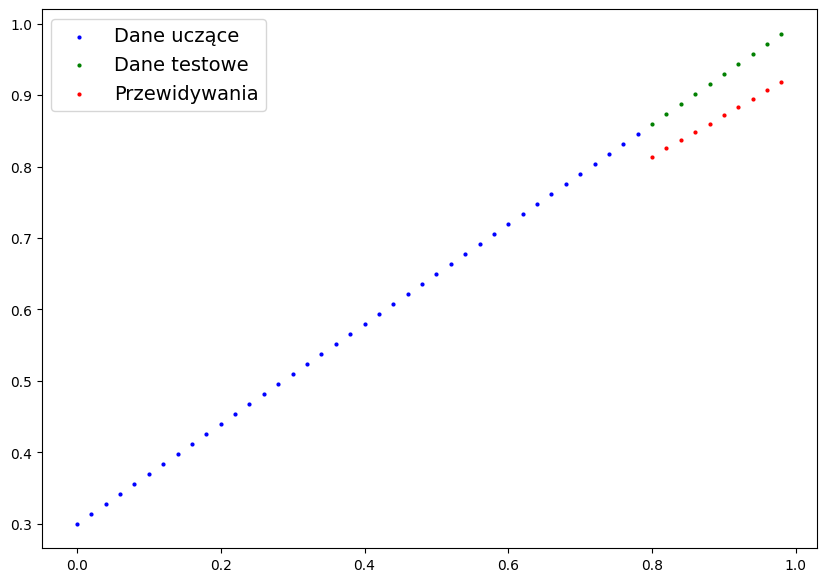

In [ ]:
plot_predictions(predictions=y_preds)

Hura! Te czerwone kropki wyglądają dużo bliżej niż wcześniej!

Zacznijmy od zapisania i ponownego załadowania modelu w PyTorch.

## 5. Zapisywanie i ładowanie modelu PyTorch

Jeśli wytrenowałeś model PyTorch, prawdopodobnie będziesz chciał go gdzieś zapisać i wyeksportować.

Na przykład, możesz trenować go w Google Colab lub na lokalnej maszynie z procesorem graficznym, ale chciałbyś teraz wyeksportować go do jakiejś aplikacji, w której inni mogliby z niego korzystać.

A może chciałbyś zapisać swoje postępy w pracy nad modelem i wrócić do niego później.

Do zapisywania i ładowania modeli w PyTorch istnieją trzy główne metody, o których powinieneś wiedzieć (wszystkie poniższe zostały zaczerpnięte z [PyTorch saving and loading models guide](https://pytorch.org/tutorials/beginner/saving_loading_models.html#saving-loading-model-for-inference)):

| Metoda PyTorch | Co robi? |
| ----- | ----- |
| [`torch.save`](https://pytorch.org/docs/stable/torch.html?highlight=save#torch.save) | Zapisuje serializowany obiekt na dysk używając narzędzia Pythona [`pickle`](https://docs.python.org/3/library/pickle.html). Modele, tensory i różne inne obiekty Pythona, takie jak słowniki, mogą być zapisywane za pomocą `torch.save`.  |
| [`torch.load`](https://pytorch.org/docs/stable/torch.html?highlight=torch%20load#torch.load) | Używa funkcji `pickle` do deserializacji i ładowania piklowanych plików obiektów Pythona (takich jak modele, tensory lub słowniki) do pamięci. Można również ustawić urządzenie, na które obiekt ma zostać załadowany (CPU, GPU itp.). |
| [`torch.nn.Module.load_state_dict`](https://pytorch.org/docs/stable/generated/torch.nn.Module.html?highlight=load_state_dict#torch.nn.Module.load_state_dict)| Wczytuje słownik parametrów modelu (`model.state_dict()`) używając zapisanego obiektu `state_dict()`. |

> **Uwaga:** Jak stwierdzono w [dokumentacji Pythona `pickle`](https://docs.python.org/3/library/pickle.html), moduł `pickle` **nie jest bezpieczny**. Oznacza to, że powinieneś zawsze rozpakowywać (ładować) tylko te dane, którym ufasz. Dotyczy to również ładowania modeli PyTorch. Używaj tylko zapisanych modeli PyTorch z zaufanych źródeł.

### Zapisywanie `state_dict()` modelu PyTorch.

[Zalecany sposób](https://pytorch.org/tutorials/beginner/saving_loading_models.html#saving-loading-model-for-inference) zapisywania i wczytywania modelu do wnioskowania (tworzenia prognoz) polega na zapisywaniu i wczytywaniu `state_dict()` modelu.

Zobaczmy, jak możemy to zrobić w kilku krokach:

1. Utworzymy katalog do zapisywania modeli o nazwie `models` przy użyciu modułu `pathlib` Pythona.
2. Utworzymy ścieżkę do pliku, w którym zapiszemy model.
3. Wywołamy `torch.save(obj, f)`, gdzie `obj` to `state_dict()` modelu docelowego, a `f` to nazwa pliku, w którym ma zostać zapisany model.

> **Uwaga:** Powszechnym zwyczajem jest, że zapisane modele lub obiekty PyTorcha kończą się na `.pt` lub `.pth`, jak `saved_model_01.pth`.

In [ ]:
from pathlib import Path

# 1. Buduje słownik modelu
MODEL_PATH = Path("Modele")
MODEL_PATH.mkdir(parents=True, exist_ok=True)

# 2. Tworzy sieżkę modelu
MODEL_NAME = "Ćw.2_model_0.pth"
MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME

# 3. Zapamiętujemy parametry modelu
print(f"Saving model to: {MODEL_SAVE_PATH}")
torch.save(obj=model_0.state_dict(), #  state_dict() zapamiętujemy parametry
           f=MODEL_SAVE_PATH)

Saving model to: Modele/Ćw.2_model_0.pth


In [ ]:
# Sprawdzenie ścieżki
!ls -l models/Ćw.2_model_0.pth

ls: cannot access 'models/Ćw.2_model_0.pth': No such file or directory


### Ładowanie `state_dict()` zapisanego modelu PyTorch

Ponieważ mamy teraz zapisany model `state_dict()` w `models/01_pytorch_workflow_model_0.pth` możemy go teraz załadować za pomocą `torch.nn.Module.load_state_dict(torch.load(f))`, gdzie `f` jest ścieżką pliku naszego zapisanego modelu `state_dict()`.

Dlaczego wywoływać `torch.load()` wewnątrz `torch.nn.Module.load_state_dict()`?

Ponieważ zapisaliśmy tylko `state_dict()` modelu, który jest słownikiem poznanych parametrów, a nie *cały* model, najpierw musimy załadować `state_dict()` za pomocą `torch.load()`, a następnie przekazać ten `state_dict()` do nowej instancji naszego modelu (która jest podklasą `nn.Module`).

Dlaczego nie zapisać całego modelu?

[Zapisywanie całego modelu](https://pytorch.org/tutorials/beginner/saving_loading_models.html#save-load-entire-model) zamiast tylko:

> Wadą tego podejścia *(zapisywania całego modelu)* jest to, że zserializowane dane są powiązane z określonymi klasami i dokładną strukturą katalogów używaną podczas zapisywania modelu...
>
> Z tego powodu kod może się zepsuć na różne sposoby, gdy jest używany w innych projektach lub po refaktoryzacji.

Zamiast tego używamy elastycznej metody zapisywania i ładowania tylko `state_dict()`, który jest zasadniczo słownikiem parametrów modelu.

Przetestujmy to, tworząc kolejną instancję `ModelRegresjiLiniowej()`, która jest podklasą `torch.nn.Module` i będzie miała wbudowaną metodę `load_state_dict()`.

In [ ]:
# Utwórz nową instancję naszego modelu (zostanie ona utworzona z losowymi wagami)
loaded_model_0 = ModelRegresjiLiniowej()

# Załaduj state_dict naszego zapisanego modelu (spowoduje to zaktualizowanie nowego wystąpienia naszego modelu o wytrenowane wagi)
loaded_model_0.load_state_dict(torch.load(f=MODEL_SAVE_PATH))

<All keys matched successfully>

Świetnie! Wygląda na to, że wszystko się zgadza.

Aby przetestować nasz załadowany model, wykonajmy z nim wnioskowanie (przewidywanie) na danych testowych.

Pamiętasz zasady wykonywania wnioskowania z modelami PyTorch?

Jeśli nie, oto przypomnienie:
<details>
    <summary>PyTorch inference rules</summary>
    <ol>
      <li> Ustaw model w trybie oceny (<code>model.eval()</code>). </li>
      <li> Dokonaj prognoz, korzystając z menedżera kontekstu trybu wnioskowania(<code>with torch.inference_mode(): ...</code>). </li>
      <li>Wszystkie prognozy powinny być dokonywane na podstawie obiektów znajdujących się na tym samym urządzeniu (np. dane i model tylko na GPU lub dane i model tylko na CPU).</li>
    </ol>
</details>



In [ ]:
# 1. Przełącz załadowany model w tryb oceny
loaded_model_0.eval()

# 2.Użyj menedżera kontekstu trybu wnioskowania, aby dokonać predykcji
with torch.inference_mode():
    loaded_model_preds = loaded_model_0(X_test) # wykonaj propagację w przód na danych testowych

Teraz dokonaliśmy pewnych przewidywań za pomocą załadowanego modelu, zobaczmy, czy są takie same, jak poprzednie przewidywania.

In [ ]:
# Porównaj poprzednie przewidywania modelu z załadowanymi przewidywaniami modelu (powinny być takie same)
y_preds == loaded_model_preds

tensor([[True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True]])

Super!

Wygląda na to, że załadowane przewidywania modelu są takie same, jak przewidywania poprzedniego modelu (przewidywania dokonane przed zapisaniem). Oznacza to, że nasz model jest zapisywany i ładowany zgodnie z oczekiwaniami.

> **Uwaga:** Istnieje więcej metod zapisywania i ładowania modeli PyTorch, ale pozostawię je do wykorzystania poza programem nauczania i do dalszej lektury. Więcej informacji znajdziesz w [przewodniku PyTorch dotyczącym zapisywania i ładowania modeli](https://pytorch.org/tutorials/beginner/saving_loading_models.html#saving-and-loading-models).

## 6. Składanie tego wszystkiego w całość

Do tej pory prześledziliśmy spory kawałek terenu.

Ale kiedy już nabędziesz trochę praktyki, będziesz wykonywać powyższe kroki jak taniec na ulicy.

Skoro już mowa o praktyce, zbierzmy w jedną całość wszystko, co do tej pory zrobiliśmy.

Z wyjątkiem tego, że tym razem sprawimy, że nasz kod będzie niezależny od urządzenia (więc jeśli jest dostępny procesor graficzny, użyje go, a jeśli nie, domyślnie będzie to procesor).

W tej sekcji będzie znacznie mniej komentarzy niż powyżej, ponieważ to, przez co będziemy przechodzić, zostało już omówione.

Zaczniemy od zaimportowania potrzebnych nam standardowych bibliotek.

> **Uwaga:** Jeśli używasz Google Colab, aby skonfigurować procesor graficzny, przejdź do Środowisko wykonawcze -> Zmień typ środowiska wykonawczego -> Akcelerator sprzętowy -> GPU. Jeśli to zrobisz, środowisko wykonawcze Colab zostanie zresetowane i utracisz zapisane zmienne.

In [ ]:
# Zaimportuj PyTorch i matplotlib
import torch
from torch import nn # nn zawiera wszystkie elementy składowe PyTorch dla sieci neuronowych
import matplotlib.pyplot as plt

# Sprawdź wersję PyTorch
torch.__version__

'2.10.0+cu128'

Teraz zacznijmy czynić nasz kod niezależnym od urządzenia, ustawiając `device="cuda"`, jeśli jest dostępne, w przeciwnym razie domyślnie będzie to `device="cpu"`.



In [ ]:
# Sparwdź device agnostic code
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Sprzęt: {device}")

Sprzęt: cuda


Jeśli masz dostęp do procesora graficznego, powyższe powinno zostać wydrukowane:

```
Sprzęt: cuda
```
W przeciwnym razie do poniższych obliczeń będziesz używać procesora. Jest to dobre rozwiązanie w przypadku naszego małego zbioru danych, ale w przypadku większych zbiorów danych zajmie to więcej czasu.

### 6.1 Dane

Stwórzmy trochę danych tak jak poprzednio.

Najpierw zakodujemy na stałe niektóre wartości „wagi” i „odchylenia”.

Następnie utworzymy zakres liczb od 0 do 1, będą to nasze wartości `X`.

Na koniec użyjemy wartości „X”, a także wartości „waga” i „odchylenie”, aby utworzyć „y” za pomocą wzoru regresji liniowej („y = waga * X + odchylenie”).

In [ ]:
# Zadeklaruj wagi i obciążenie
weight = 0.7
bias = 0.3

# Utwórz zakres wartości
start = 0
end = 1
step = 0.02

# Utwórz X i y (cechy i etykiety)
X = torch.arange(start, end, step).unsqueeze(dim=1) # bez unsqueeze błędy wystąpią później (kształty w warstwach liniowych)
y = weight * X + bias
X[:10], y[:10]

(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800],
         [0.1000],
         [0.1200],
         [0.1400],
         [0.1600],
         [0.1800]]),
 tensor([[0.3000],
         [0.3140],
         [0.3280],
         [0.3420],
         [0.3560],
         [0.3700],
         [0.3840],
         [0.3980],
         [0.4120],
         [0.4260]]))

Super!

Mamy już trochę danych, podzielmy je na zbiory uczące i testowe.

Zastosujemy podział 80/20 z 80% danymi treningowymi i 20% danymi testowymi.

In [ ]:
# Podziel dane
train_split = int(0.8 * len(X))
X_train, y_train = X[:train_split], y[:train_split]
X_test, y_test = X[train_split:], y[train_split:]

len(X_train), len(y_train), len(X_test), len(y_test)

(40, 40, 10, 10)

Świetnie. Zwizualizujmy je i upewnijmy się, że wyglądają dobrze

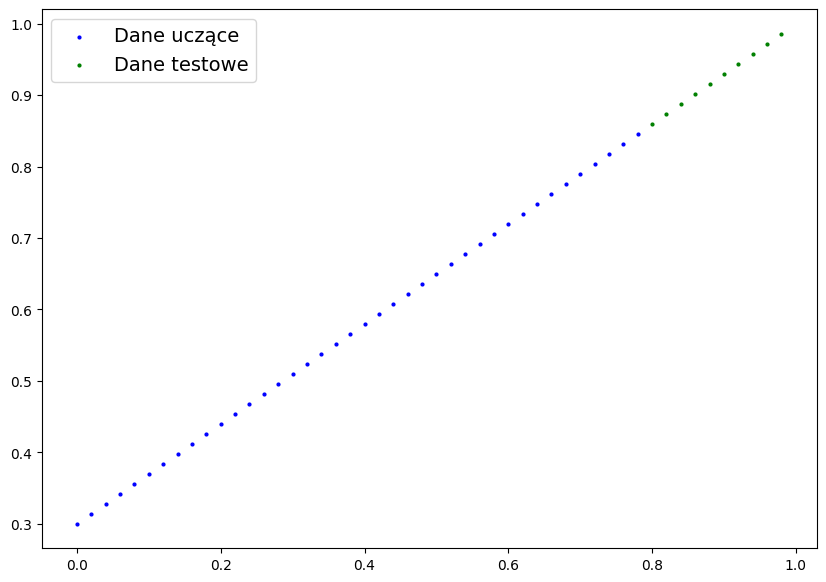

In [ ]:
# Uwaga: jeśli zresetujesz środowisko wykonawcze, ta funkcja nie będzie działać,
# będziesz musiał ponownie uruchomić komórkę powyżej, w której została utworzona.
plot_predictions(X_train, y_train, X_test, y_test)

### 6.2 Budowa modelu liniowego PyTorch

Mamy już pewne dane, teraz czas na wykonanie modelu.

Stworzymy model w tym samym stylu, co poprzednio, z tą różnicą, że zamiast ręcznie definiować parametry wagi i odchylenia naszego modelu za pomocą `nn.Parameter()`, użyjemy [`nn.Linear(in_features, out_features)`](https://pytorch.org/docs/stable/generated/torch.nn.Linear.html), aby zrobić to za nas.

Gdzie „in_features” to liczba wymiarów, jakie mają dane wejściowe, a „out_features” to liczba wymiarów, do których mają być one wysyłane.

W naszym przypadku oba mają wartość „1”, ponieważ nasze dane mają jedną cechę wejściową („X”) na etykietę („y”).

Tworzenie modelu regresji liniowej przy użyciu `nn.Parameter` kontra użycie `nn.Linear`.

In [ ]:
from IPython.display import Image
Image('./Obraz7.png')

FileNotFoundError: No such file or directory: './Obraz7.png'

FileNotFoundError: No such file or directory: './Obraz7.png'

<IPython.core.display.Image object>

In [ ]:
# Budowa modelu regersji liniowej w PyTorch i nn.Linear
# Korzystamy z nn.Module
class ModelRegresjiLiniowej2(nn.Module):
    def __init__(self):
        super().__init__()
        # korzystamy z nn.Linear() dla wyznaczenia parametrów modelu
        self.linear_layer = nn.Linear(in_features=1,
                                      out_features=1)

# Definiujemy obliczenia do przodu (forward pass)
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.linear_layer(x)


torch.manual_seed(42)
model_1 = ModelRegresjiLiniowej2()
model_1, model_1.state_dict()

(ModelRegresjiLiniowej2(
   (linear_layer): Linear(in_features=1, out_features=1, bias=True)
 ),
 OrderedDict([('linear_layer.weight', tensor([[0.7645]])),
              ('linear_layer.bias', tensor([0.8300]))]))

Zwróć uwagę na wyniki funkcji `model_1.state_dict()`, warstwa `nn.Linear()` utworzyła dla nas losowy parametr `weight` i `bias`.

Teraz umieśćmy nasz model na GPU (jeśli jest dostępny).

Możemy zmienić urządzenie, na którym znajdują się nasze obiekty PyTorch, używając `.to(device)`.

Najpierw sprawdźmy aktualne urządzenie modelu.

In [ ]:
# Sprawdź urządzenie-device
next(model_1.parameters()).device

device(type='cpu')

Cudownie, wygląda na to, że model jest domyślnie na procesorze.

Zmieńmy to tak, żeby było na GPU (jeśli jest dostępne).

In [ ]:
# Ustaw model na GPU, jeśli jest dostępny, w przeciwnym razie domyślnym ustawieniem będzie CPU
model_1.to(device) # urządzenie zostało ustawione na „cuda”, jeśli jest dostępne, lub „cpu”, jeśli nie
next(model_1.parameters()).device

device(type='cuda', index=0)

Super! Ze względu na nasz kod niezależny od urządzenia, powyższa komórka będzie działać niezależnie od tego, czy procesor graficzny jest dostępny, czy nie.

Jeśli masz dostęp do procesora graficznego obsługującego CUDA, powinieneś zobaczyć wynik podobny do:

```
device(type='cuda', index=0)
```

### 6.3 Uczenie

Czas zbudować pętlę ucząco-testową.

Najpierw będziemy potrzebować funkcji straty i optymalizatora.

Użyjmy tych samych funkcji, których używaliśmy wcześniej, `nn.L1Loss()` i `torch.optim.SGD()`.

Będziemy musieli przekazać parametry nowego modelu („model.parameters()”) optymalizatorowi, aby mógł je dostosować podczas uczenia.

Szybkość uczenia się wynosząca „0,01” wcześniej działała dobrze, więc wykorzystajmy ją ponownie.




In [ ]:
# Utwórz funkcję straty
loss_fn = nn.L1Loss()

# Wybierz optymalizator
optimizer = torch.optim.SGD(params=model_1.parameters(), # optymalizacja parametrów nowo utworzonego modelu
                            lr=0.01)

Funkcja straty i optymalizator gotowe, teraz trenujmy i oceniajmy nasz model za pomocą pętli uczącej i testowej.

Jedyną rzeczą, którą będziemy robić w tym kroku w porównaniu z poprzednią pętlą uczącą, będzie umieszczenie danych na docelowym „urządzeniu”.

Umieściliśmy już nasz model na docelowym „urządzeniu” za pomocą `model_1.to(device)`.

To samo możemy zrobić z danymi.

W ten sposób, jeśli model znajduje się na GPU, dane znajdują się na GPU (i odwrotnie).

Tym razem podnieśmy poprzeczkę i ustawmy „epoki = 1000”.

Jeśli potrzebujesz przypomnienia o krokach pętli uczącej PyTorch, zobacz poniżej.

<details>
    <summary>Kroki pętli PyTorch</summary>
    <ol>
        <li><b>Forward pass</b> - The model goes through all of the training data once, performing its
            <code>forward()</code> function
            calculations (<code>model(x_train)</code>).
        </li>
        <li><b>Calculate the loss</b> - The model's outputs (predictions) are compared to the ground truth and evaluated
            to see how
            wrong they are (<code>loss = loss_fn(y_pred, y_train</code>).</li>
        <li><b>Zero gradients</b> - The optimizers gradients are set to zero (they are accumulated by default) so they
            can be
            recalculated for the specific training step (<code>optimizer.zero_grad()</code>).</li>
        <li><b>Perform backpropagation on the loss</b> - Computes the gradient of the loss with respect for every model
            parameter to
            be updated (each parameter
            with <code>requires_grad=True</code>). This is known as <b>backpropagation</b>, hence "backwards"
            (<code>loss.backward()</code>).</li>
        <li><b>Step the optimizer (gradient descent)</b> - Update the parameters with <code>requires_grad=True</code>
            with respect to the loss
            gradients in order to improve them (<code>optimizer.step()</code>).</li>
    </ol>
</details>

In [ ]:
torch.manual_seed(42)

# Ustal liczbę epok
epochs = 1000

# Umieść dane na dostępnym urządzeniu
# Bez tego wystąpi błąd (nie wszystkie modele/dane na urządzeniu)
X_train = X_train.to(device)
X_test = X_test.to(device)
y_train = y_train.to(device)
y_test = y_test.to(device)

for epoch in range(epochs):
    ### Uczenie
    model_1.train() # moduł uczenia

    # 1. Krok do przodu/propagacja w przód
    y_pred = model_1(X_train)

    # 2. Obliczenie odległości między wartościami otrzymanymi przez model a wartościami rzeczywistymi
    loss = loss_fn(y_pred, y_train)

    # 3. Gradienty równe zero
    optimizer.zero_grad()

    # 4. Oblicz propagację wsteczną
    loss.backward()

    # 5. Zaktualizuj parametry
    optimizer.step()

    ### Testowanie
    model_1.eval() # przełączenie modelu w tryb oceny w celu testowania (wnioskowania)
    # 1. Krok do przodu
    with torch.inference_mode():
        test_pred = model_1(X_test)

        # 2. Oblicz stratę
        test_loss = loss_fn(test_pred, y_test)

    if epoch % 100 == 0:
        print(f"Epoka: {epoch} | Strata uczenia (Train loss): {loss} | Strata testowa (Test loss): {test_loss}")

Epoka: 0 | Strata uczenia (Train loss): 0.5551779270172119 | Strata testowa (Test loss): 0.5739762187004089
Epoka: 100 | Strata uczenia (Train loss): 0.006215683650225401 | Strata testowa (Test loss): 0.014086711220443249
Epoka: 200 | Strata uczenia (Train loss): 0.0012645035749301314 | Strata testowa (Test loss): 0.013801801018416882
Epoka: 300 | Strata uczenia (Train loss): 0.0012645035749301314 | Strata testowa (Test loss): 0.013801801018416882
Epoka: 400 | Strata uczenia (Train loss): 0.0012645035749301314 | Strata testowa (Test loss): 0.013801801018416882
Epoka: 500 | Strata uczenia (Train loss): 0.0012645035749301314 | Strata testowa (Test loss): 0.013801801018416882
Epoka: 600 | Strata uczenia (Train loss): 0.0012645035749301314 | Strata testowa (Test loss): 0.013801801018416882
Epoka: 700 | Strata uczenia (Train loss): 0.0012645035749301314 | Strata testowa (Test loss): 0.013801801018416882
Epoka: 800 | Strata uczenia (Train loss): 0.0012645035749301314 | Strata testowa (Test l

> **Uwaga:** ze względu na losowy charakter uczenia maszynowego prawdopodobnie uzyskasz nieco inne wyniki (różne wartości strat i przewidywań) w zależności od tego, czy Twój model został wyszkolony na procesorze CPU czy GPU. Dzieje się tak nawet wtedy, gdy używasz tego samego losowego materiału siewnego na którymkolwiek urządzeniu. Jeśli różnica jest duża, możesz poszukać błędów, jeśli jednak jest mała (idealnie jest), możesz ją zignorować.

Super! Ta strata wygląda na dość niską.

Sprawdźmy parametry, których nauczył się nasz model i porównajmy je z oryginalnymi parametrami, które zakodowaliśmy.

In [ ]:
# Znajdź wyuczone parametry naszego modelu
from pprint import pprint # pprint = pretty print, zobacz: https://docs.python.org/3/library/pprint.html
print("Model nauczył się następujących wartości wag i odchylenia:")
pprint(model_1.state_dict())
print("\nA oryginalne wartości wag i obciązeń to:")
print(f"weights: {weight}, bias: {bias}")

Model nauczył się następujących wartości wag i odchylenia:
OrderedDict([('linear_layer.weight', tensor([[0.6968]], device='cuda:0')),
             ('linear_layer.bias', tensor([0.3025], device='cuda:0'))])

A oryginalne wartości wag i obciązeń to:
weights: 0.7, bias: 0.3


To już  blisko idealnego modelu.

Pamiętaj jednak, że w praktyce rzadko zdarza się, aby z wyprzedzeniem znać idealne parametry.

A gdybyś wiedział, jakich parametrów model musi się nauczyć z wyprzedzeniem, jaka byłaby zabawa w uczeniu maszynowym?

Ponadto w wielu rzeczywistych problemach związanych z uczeniem maszynowym liczba parametrów może znacznie przekraczać dziesiątki milionów.


### 6.4 Przewidywanie

Teraz mamy wytrenowany model, włączmy jego tryb oceny i dokonajmy pewnych przewidywań.

In [ ]:
# Zmień model w tryb oceny
model_1.eval()

# Wykonaj prognozę na danych testowych
with torch.inference_mode():
    y_preds = model_1(X_test)
y_preds

tensor([[0.8600],
        [0.8739],
        [0.8878],
        [0.9018],
        [0.9157],
        [0.9296],
        [0.9436],
        [0.9575],
        [0.9714],
        [0.9854]], device='cuda:0')

Jeśli dokonujesz prognoz na podstawie danych na GPU, możesz zauważyć, że wynik powyższego ma na końcu `device='cuda:0'`. Oznacza to, że dane znajdują się na urządzeniu CUDA 0 (pierwszym procesorze graficznym, do którego system ma dostęp ze względu na indeksowanie zerowe). Jeśli w przyszłości będziesz używać wielu procesorów graficznych, liczba ta może być wyższa.

Teraz narysujmy przewidywania naszego modelu.

> **Uwaga:** wiele bibliotek do nauki o danych, takich jak pandas, matplotlib i NumPy, nie jest w stanie korzystać z danych przechowywanych na GPU. Możesz więc napotkać pewne problemy podczas próby użycia funkcji z jednej z tych bibliotek z danymi tensorowymi, które nie są przechowywane w procesorze. Aby to naprawić, możesz wywołać funkcję [`.cpu()`](https://pytorch.org/docs/stable/generated/torch.Tensor.cpu.html) na docelowym tensorze, aby zwrócić kopię docelowego tensora na procesorze.

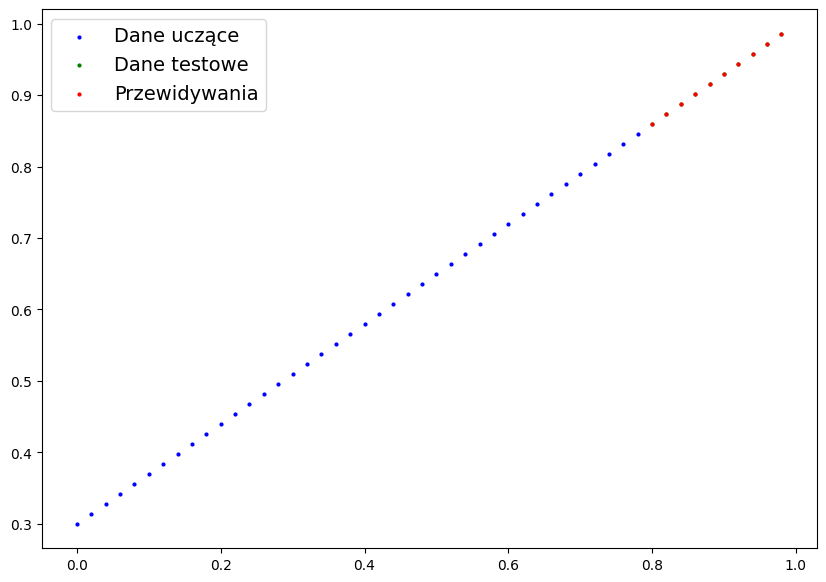

In [ ]:
# plot_predictions(predictions=y_preds) # -> nie będzie działać... dane nie na procesorze

# Umieść dane na procesorze i zrób wykres
plot_predictions(predictions=y_preds.cpu())

 Spójrz na te czerwone kropki, pokrywają się niemal idealnie z zielonymi kropkami. Myślę, że dodatkowe epoki pomogły.



### 6.5 Zapisywanie i ładowanie modelu

Jesteśmy zadowoleni z przewidywań naszych modeli, więc zapiszmy je w pliku, aby można było z nich skorzystać później.


In [ ]:
from pathlib import Path

# 1. Tworzy słownik modelu
MODEL_PATH = Path("models")
MODEL_PATH.mkdir(parents=True, exist_ok=True)

# 2. Tworzy ścieżkę do zapisu modelu
MODEL_NAME = "Ćw2_workflow_model_1.pth"
MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME

# 3. Zapamiętanie state dict
print(f"Zapisywanie modelu do: {MODEL_SAVE_PATH}")
torch.save(obj=model_1.state_dict(), # tylko zapisywanie state_dict() zapisuje tylko wyuczone parametry modeli
           f=MODEL_SAVE_PATH)

Zapisywanie modelu do: models/Ćw2_workflow_model_1.pth


Aby mieć pewność, że wszystko działa prawidłowo, załadujmy go ponownie.

Dobrze:
* Utwórz nową instancję klasy `ModelRegresjiLiniowej2()`
* Załaduj dykt stanu modelu za pomocą `torch.nn.Module.load_state_dict()`
* Wyślij nową instancję modelu do urządzenia docelowego (aby mieć pewność, że nasz kod jest niezależny od urządzenia)

In [ ]:
# Zainicjowanie nowego wystąpienia ModelRegresjiLiniowej2
loaded_model_1 = ModelRegresjiLiniowej2()

# Załadowanie model state dict
loaded_model_1.load_state_dict(torch.load(MODEL_SAVE_PATH))

#  Umieść model na urządzeniu docelowym (jeśli dane znajdują się na GPU, model będzie musiał znajdować się na GPU, aby tworzyć prognozy).
loaded_model_1.to(device)

print(f"Model zapamiętany na:\n{loaded_model_1}")
print(f"Model na urządzeniu:\n{next(loaded_model_1.parameters()).device}")

Model zapamiętany na:
ModelRegresjiLiniowej2(
  (linear_layer): Linear(in_features=1, out_features=1, bias=True)
)
Model na urządzeniu:
cuda:0


Teraz możemy ocenić załadowany model, aby sprawdzić, czy nasze prognozy pokrywają się z tymi zrobionymi przez zapisaniem modelu.

In [ ]:
# Oceń załadowany model
loaded_model_1.eval()
with torch.inference_mode():
    loaded_model_1_preds = loaded_model_1(X_test)
y_preds == loaded_model_1_preds

tensor([[True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True]], device='cuda:0')

Koniec!

Cóż, przebyliśmy długą drogę. Zbudowałeś i wytrenowałeś swoje pierwsze dwa modele sieci neuronowych w PyTorch!

Czas poćwiczyć swoje umiejętności.

## Zadania


> **Uwaga:** w przypadku wszystkich ćwiczeń kod powinien być niezależny od urządzenia (co oznacza, że ​​może działać na procesorze lub karcie graficznej, jeśli jest dostępny).

1. Utwórz prosty zbiór danych, korzystając ze wzoru regresji liniowej („waga * X + odchylenie”).
  * Ustaw `weight=0,3` i `bias=0,9`, łącznie powinno być co najmniej 100 punktów danych.
  * Podziel dane na 80% treningowe, 20% testowe.
  * Narysuj dane szkoleniowe i testowe tak, aby były widoczne.
2. Zbuduj model PyTorch poprzez podklasę `nn.Module`.
  * Wewnątrz powinna znajdować się losowo inicjowana funkcja `nn.Parameter()` z wartością `requires_grad=True`, jedna dla `wagi` i druga dla `bias`.
  * Zaimplementuj metodę „forward()”, aby obliczyć funkcję regresji liniowej użytej do utworzenia zbioru danych w 1.
  * Po skonstruowaniu modelu utwórz jego instancję i sprawdź jego funkcję `state_dict()`.
  * **Uwaga:** Jeśli chcesz użyć `nn.Linear()` zamiast `nn.Parameter()`, możesz to zrobić.
3. Utwórz funkcję straty i optymalizator, używając odpowiednio `nn.L1Loss()` i `torch.optim.SGD(params, lr)`.
  * Ustaw szybkość uczenia optymalizatora na 0,01, a parametry do optymalizacji powinny być parametrami modelu z modelu utworzonego w części 2.
  * Napisz pętlę treningową, aby wykonać odpowiednie kroki szkoleniowe dla 300 epok.
  * Pętla treningowa powinna testować model na testowym zbiorze danych co 20 epok.
4. Dokonaj przewidywań za pomocą przeszkolonego modelu na danych testowych.
  * Wizualizuj te przewidywania w porównaniu z oryginalnymi danymi szkoleniowymi i testowymi (**uwaga:** może być konieczne upewnienie się, że przewidywania *nie* znajdują się na GPU, jeśli chcesz używać do kreślenia bibliotek nie obsługujących CUDA, takich jak matplotlib).
5. Zapisz funkcję „state_dict()” wyszkolonego modelu do pliku.
  * Utwórz nową instancję klasy modelu, którą utworzyłeś w punkcie 2 i załaduj funkcję `state_dict()`, którą właśnie w niej zapisałeś.
  * Wykonaj prognozy na danych testowych za pomocą załadowanego modelu i potwierdź, że odpowiadają one przewidywaniom oryginalnego modelu z punktu 4.



* Przeczytaj [What is `torch.nn`, really?](https://pytorch.org/tutorials/beginner/nn_tutorial.html) autorstwa Jeremy'ego Howarda w celu głębszego zrozumienia działania jednego z najważniejszych modułów PyTorch.
* Poświęć 10 minut na przewijanie i sprawdzanie [PyTorch documentation cheatsheet](https://pytorch.org/tutorials/beginner/ptcheat.html) dla wszystkich różnych modułów PyTorch, z którymi możesz się spotkać.
* Poświęć 10 minut na przeczytanie [dokumentacji ładowania i zapisywania w witrynie PyTorch](https://pytorch.org/tutorials/beginner/saving_loading_models.html), aby lepiej zapoznać się z różnymi opcjami zapisywania i ładowania w PyTorch.
* Poświęć 1-2 godziny na przeczytanie/obejrzenie poniższego, aby zapoznać się z wewnętrznymi elementami opadania gradientu i propagacji wstecznej, dwóch głównych algorytmów, które działały w tle, aby pomóc naszemu modelowi w uczeniu się.
 * [Strona Wikipedii poświęcona spadkowi gradientowemu](https://pl.wikipedia.org/wiki/Metoda_najszybszego_spadku)
 * [Algorithm Descent – ​​głębokie nurkowanie](https://towardsdatascience.com/gradient-descent-algorithm-a-deep-dive-cf04e8115f21) Roberta Kwiatkowskiego
 * [Spadek gradientowy, jak sieci neuronowe uczą się wideo](https://youtu.be/IHZwWFHWa-w) autor: 3Blue1Brown
 * [Co tak naprawdę robi propagacja wsteczna?](https://youtu.be/Ilg3gGewQ5U) film autorstwa 3Blue1Brown
 * [Strona Wikipedii na temat wstecznej propagacji](https://en.wikipedia.org/wiki/Backpropagation)
